# import Libraries

In [256]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
%matplotlib inline
from datetime import datetime 

In [257]:
df=pd.read_csv("data/cleaned_chargingdata.csv")
df.head(25)

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,250.0,25.00,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,280.0,70.00,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,400.0,8.00,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00
4,4,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00
5,5,4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,400.0,16.00,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00
6,6,5,5e23b149f9af8b5fe4b973d4,2020-01-02 06:00:13-08:00,2020-01-02 15:00:41-08:00,2020-01-02 12:13:21-08:00,13.370,1_1_194_821_2020-01-02 14:00:05.241573,1,AG-1F13,1-1-194-821,America/Los_Angeles,3519.0,600.0,24.00,40.0,624.0,2020-01-02 06:00:12-08:00,True,2020-01-02 16:24:13-08:00
7,7,6,5e23b149f9af8b5fe4b973d5,2020-01-02 06:09:14-08:00,2020-01-02 17:57:58-08:00,2020-01-02 16:59:21-08:00,43.477,1_1_178_817_2020-01-02 14:09:14.451827,1,AG-1F09,1-1-178-817,America/Los_Angeles,933.0,385.0,65.45,170.0,647.0,2020-01-02 06:09:33-08:00,True,2020-01-02 16:56:14-08:00
8,8,7,5e23b149f9af8b5fe4b973d6,2020-01-02 06:17:32-08:00,2020-01-02 16:44:54-08:00,2020-01-02 12:22:40-08:00,32.441,1_1_191_804_2020-01-02 14:17:32.329535,1,AG-4F34,1-1-191-804,America/Los_Angeles,3737.0,300.0,45.00,150.0,126.0,2020-01-02 06:17:40-08:00,True,2020-01-02 08:23:32-08:00
9,9,8,5e23b149f9af8b5fe4b973d7,2020-01-02 06:25:38-08:00,2020-01-02 11:36:05-08:00,2020-01-02 10:38:39-08:00,13.264,1_1_194_826_2020-01-02 14:25:37.578692,1,AG-1F11,1-1-194-826,America/Los_Angeles,419.0,400.0,40.00,100.0,491.0,2020-01-02 06:25:45-08:00,True,2020-01-02 14:36:38-08:00


# Time Index

In [258]:
# I don't know why the connectionTime data from the original dataset cannot be directly converted into the "hour:minute:second" format. 
# so I convert this column into local time again.
df['connectionTime'] = pd.to_datetime(df['connectionTime'],utc=True)
df.head(25)

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,250.0,25.00,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,280.0,70.00,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,400.0,8.00,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00
4,4,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.00,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00
5,5,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,400.0,16.00,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00
6,6,5,5e23b149f9af8b5fe4b973d4,2020-01-02 14:00:13+00:00,2020-01-02 15:00:41-08:00,2020-01-02 12:13:21-08:00,13.370,1_1_194_821_2020-01-02 14:00:05.241573,1,AG-1F13,1-1-194-821,America/Los_Angeles,3519.0,600.0,24.00,40.0,624.0,2020-01-02 06:00:12-08:00,True,2020-01-02 16:24:13-08:00
7,7,6,5e23b149f9af8b5fe4b973d5,2020-01-02 14:09:14+00:00,2020-01-02 17:57:58-08:00,2020-01-02 16:59:21-08:00,43.477,1_1_178_817_2020-01-02 14:09:14.451827,1,AG-1F09,1-1-178-817,America/Los_Angeles,933.0,385.0,65.45,170.0,647.0,2020-01-02 06:09:33-08:00,True,2020-01-02 16:56:14-08:00
8,8,7,5e23b149f9af8b5fe4b973d6,2020-01-02 14:17:32+00:00,2020-01-02 16:44:54-08:00,2020-01-02 12:22:40-08:00,32.441,1_1_191_804_2020-01-02 14:17:32.329535,1,AG-4F34,1-1-191-804,America/Los_Angeles,3737.0,300.0,45.00,150.0,126.0,2020-01-02 06:17:40-08:00,True,2020-01-02 08:23:32-08:00
9,9,8,5e23b149f9af8b5fe4b973d7,2020-01-02 14:25:38+00:00,2020-01-02 11:36:05-08:00,2020-01-02 10:38:39-08:00,13.264,1_1_194_826_2020-01-02 14:25:37.578692,1,AG-1F11,1-1-194-826,America/Los_Angeles,419.0,400.0,40.00,100.0,491.0,2020-01-02 06:25:45-08:00,True,2020-01-02 14:36:38-08:00


In [259]:
df['connectionTime']=df['connectionTime'].dt.tz_convert('America/Los_Angeles')
df.head()

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.0,20.0,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00
4,4,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00


In [260]:
df['connectionTime']= pd.to_datetime(df['connectionTime']).dt.strftime('%Y-%m-%d %H:%M:%S')
df.head()

,Unnamed: 0.1,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00
1,1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00
2,2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00
3,3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.0,20.0,65.0,2020-01-02 06:00:03-08:00,True,2020-01-02 07:04:58-08:00
4,4,3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00


In [261]:
df['time']=df['connectionTime']
df['time']=pd.to_datetime(df['time'])
df=df.set_index('time')

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 75329 entries, 2020-01-02 05:08:54 to 2019-07-31 12:21:47
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0.1        75329 non-null  int64  
 1   Unnamed: 0          75329 non-null  int64  
 2   id                  75329 non-null  object 
 3   connectionTime      75329 non-null  object 
 4   disconnectTime      75329 non-null  object 
 5   doneChargingTime    75329 non-null  object 
 6   kWhDelivered        75329 non-null  float64
 7   sessionID           75329 non-null  object 
 8   siteID              75329 non-null  int64  
 9   spaceID             75329 non-null  object 
 10  stationID           75329 non-null  object 
 11  timezone            75329 non-null  object 
 12  userID              58975 non-null  float64
 13  WhPerMile           58975 non-null  float64
 14  kWhRequested        58975 non-null  float64
 15  milesRequested    

# Separating Data by SiteID

To better understand the charging characteristics of different stations, I have divided the data into two datasets: one for Station 1 and the other for Station 2.

In [263]:
df["siteID"].unique()

array([1, 2], dtype=int64)

In [264]:
site1_Data=df[df["siteID"]==1]
site2_Data=df[df["siteID"]==2]
site1_Data.to_csv('data/site1_Data.csv', index=False)
site2_Data.to_csv('data/site2_Data.csv', index=False)

In [265]:
site1=pd.read_csv("data/site1_Data.csv")
site2=pd.read_csv("data/site2_Data.csv")

In [266]:
# Time Index
print(site1.index)
print(site2.index)
print(df.index)

RangeIndex(start=0, stop=42158, step=1)
RangeIndex(start=0, stop=33171, step=1)
DatetimeIndex(['2020-01-02 05:08:54', '2020-01-02 05:36:50',
               '2020-01-02 05:56:35', '2020-01-02 05:59:58',
               '2020-01-02 05:59:58', '2020-01-02 06:00:01',
               '2020-01-02 06:00:13', '2020-01-02 06:09:14',
               '2020-01-02 06:17:32', '2020-01-02 06:25:38',
               ...
               '2019-07-31 07:45:29', '2019-07-31 07:46:58',
               '2019-07-31 07:48:11', '2019-07-31 07:50:02',
               '2019-07-31 07:50:17', '2019-07-31 11:08:04',
               '2019-07-31 11:40:41', '2019-07-31 12:04:40',
               '2019-07-31 12:19:47', '2019-07-31 12:21:47'],
              dtype='datetime64[ns]', name='time', length=75329, freq=None)


In [267]:
site1['time']=site1['connectionTime']
site1['time']=pd.to_datetime(site1['time'])
site1=site1.set_index('time')
site2['time']=site2['connectionTime']
site2['time']=pd.to_datetime(site2['time'])
site2=site2.set_index('time')

# Temporal Patterns and Seasonality

## During the day

In [268]:
Three_years_hourly_counts=df.groupby(df.index.hour).size()
# total number of charges in the same time period (hour) across three years
Three_years_hourly_counts

time
0       179
1        78
2       105
3       182
4       565
5      3062
6      9570
7     13156
8      8712
9      6792
10     4116
11     3515
12     4290
13     3593
14     3189
15     3362
16     3026
17     2064
18     1824
19     1421
20      998
21      755
22      495
23      280
dtype: int64

In [269]:
number_of_days = len(set(df.index.date))
print(number_of_days)
hourly_avg = Three_years_hourly_counts/number_of_days
hourly_avg=hourly_avg.round().astype(int)

1110


In [332]:
# Round to the nearest integer 
hourly_counts= hourly_avg.reset_index()
hourly_counts.columns = ['Hour', 'Vehicle_charging_Count']
hourly_counts
# By dividing the total number of charging sessions per hour over three years by the number of days
# we can determine the average hourly charging frequency.

,Hour,Vehicle_charging_Count
0,0,0
1,1,0
2,2,0
3,3,0
4,4,1
5,5,3
6,6,9
7,7,12
8,8,8
9,9,6


<BarContainer object of 24 artists>

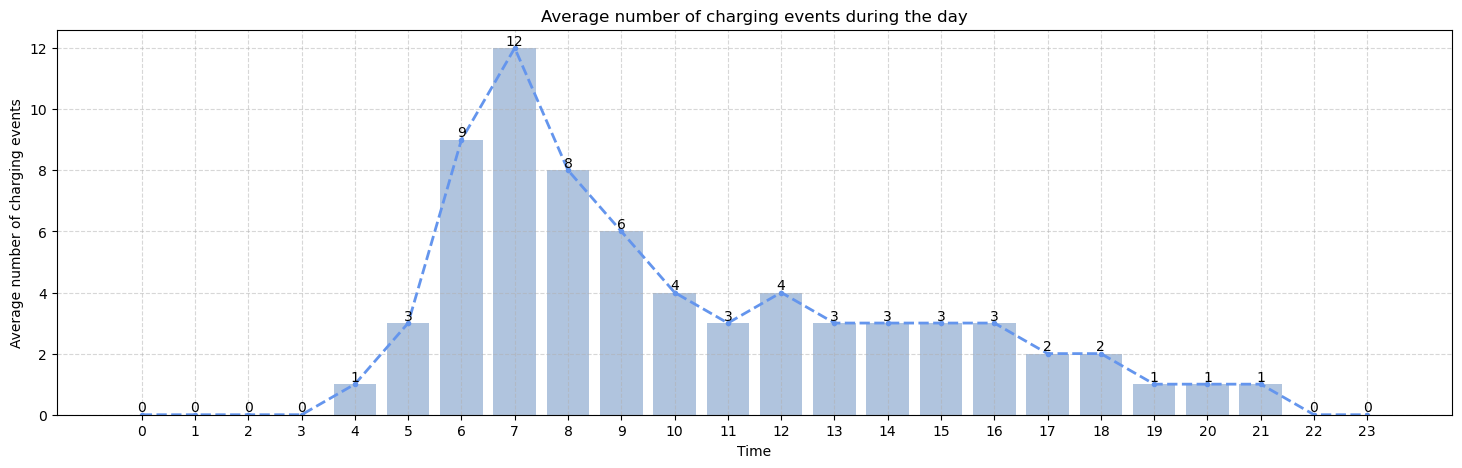

In [271]:
fig=plt.figure(figsize=(18,5))
x=hourly_counts['Hour']
y=hourly_counts['Vehicle_charging_Count']
plt.plot(x, y, color='cornflowerblue',marker='.',linestyle='--',linewidth=2,label='Line Chart')
plt.title('Average number of charging events during the day')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(x)
plt.xlabel('Time')
plt.ylabel('Average number of charging events')
plt.bar(x,y,color='lightsteelblue')

The main peak in the early morning (6-8 a.m.), particularly at 7 a.m., when people typically charge their vehicles upon arriving at work or school to prepare for their next trip. A smaller, secondary peak occurs around 11 a.m. to 12 p.m., likely due to drivers who didn’t charge in the morning using this time to top up their vehicles for afternoon or evening journeys. During the evening and early morning hours, charging events are rare because most drivers have already returned home and no longer need to charge their vehicles near schools or workplaces. Overall, the trend shows that charging demand reaches its peak in the morning, gradually decreases throughout the day, and remains stable in the evening and early morning.

#### separating site1 and site2

In [272]:
Three_years_hourly_counts_site1=site1.groupby(site1.index.hour).size()
# total number of charges in the same time period (hour) across three years
Three_years_hourly_counts_site2=site2.groupby(site2.index.hour).size()
number_of_days_site1=len(set(site1.index.date))
print(number_of_days_site1)
hourly_avg_site1=Three_years_hourly_counts_site1/number_of_days_site1
hourly_avg_site1=hourly_avg_site1.round().astype(int)
number_of_days_site2=len(set(site2.index.date))
print(number_of_days_site2)
hourly_avg_site2=Three_years_hourly_counts_site2/number_of_days_site2
hourly_avg_site2=hourly_avg_site2.round().astype(int)

886
1021


In [273]:
Three_years_hourly_counts_site1= hourly_avg_site1.reset_index()
Three_years_hourly_counts_site2= hourly_avg_site2.reset_index()
Three_years_hourly_counts_site1.columns = ['Hour', 'Vehicle_charging_Count_site1']
Three_years_hourly_counts_site2.columns = ['Hour', 'Vehicle_charging_Count_site2']
print(Three_years_hourly_counts_site1)

    Hour  Vehicle_charging_Count_site1
0      0                             0
1      1                             0
2      2                             0
3      3                             0
4      4                             0
5      5                             3
6      6                            10
7      7                            13
8      8                             3
9      9                             2
10    10                             1
11    11                             2
12    12                             3
13    13                             2
14    14                             2
15    15                             2
16    16                             2
17    17                             1
18    18                             0
19    19                             0
20    20                             0
21    21                             0
22    22                             0
23    23                             0


In [274]:
print(Three_years_hourly_counts_site2)

    Hour  Vehicle_charging_Count_site2
0      0                             0
1      1                             0
2      2                             0
3      3                             0
4      4                             0
5      5                             0
6      6                             1
7      7                             2
8      8                             6
9      9                             5
10    10                             3
11    11                             2
12    12                             2
13    13                             2
14    14                             1
15    15                             1
16    16                             1
17    17                             1
18    18                             2
19    19                             1
20    20                             1
21    21                             1
22    22                             0
23    23                             0


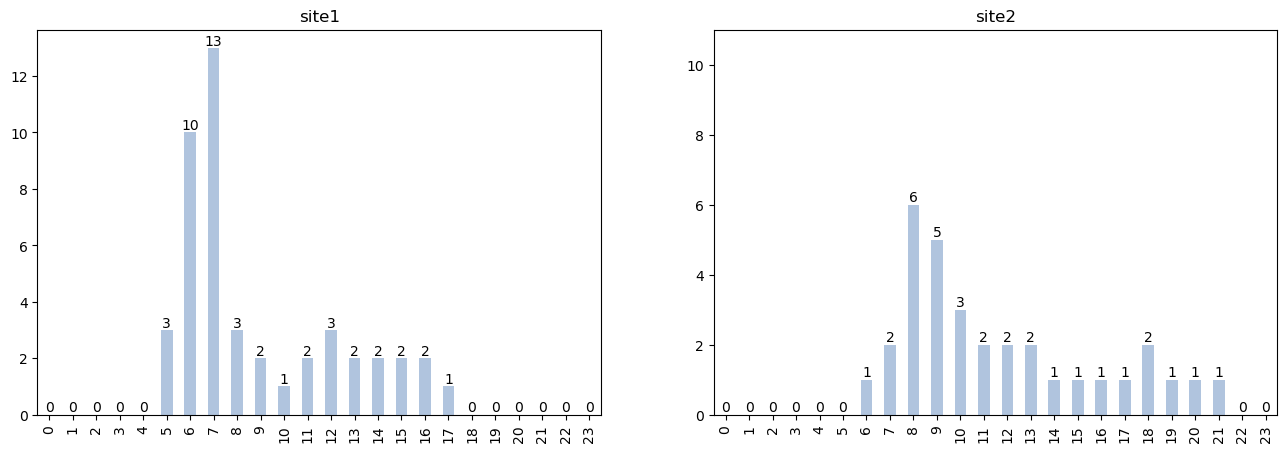

In [275]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
y_min,y_max=0,11
site1_bars=Three_years_hourly_counts_site1['Vehicle_charging_Count_site1'].plot(kind='bar',ax=ax[0],title='site1',color='lightsteelblue')
for bar in site1_bars.patches:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 
site2_bars=Three_years_hourly_counts_site2['Vehicle_charging_Count_site2'].plot(kind='bar',ax=ax[1],title='site2',color='lightsteelblue')
ax[1].set_ylim(y_min, y_max)
for bar in site2_bars.patches:
    ax[1].text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 

These are the average hourly charging frequencies for Station 1 and Station 2.The charging behavior differs significantly between the two sites, with Site 1 showing concentrated activity in the early morning and Site 2 having a broader but lower-intensity charging period in the morning.

## During the weeek

### all data

In [276]:
df.index.dayofweek

Index([3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       ...
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
      dtype='int32', name='time', length=75329)

In [277]:
# the number of weekdays
unique_dates = df.index.normalize().unique()
Monday_count =(pd.to_datetime(unique_dates).dayofweek == 0).sum()
print("Number of Mondays:",Monday_count)
Tuesday_count =(pd.to_datetime(unique_dates).dayofweek == 1).sum()
print("Number of Tuesdays:",Tuesday_count)
Wednesday_count =(pd.to_datetime(unique_dates).dayofweek == 2).sum()
print("Number of Wednesdays:",Wednesday_count)
Thursday_count =(pd.to_datetime(unique_dates).dayofweek == 3).sum()
print("Number of Thursdays:",Thursday_count)
Friday_count =(pd.to_datetime(unique_dates).dayofweek == 4).sum()
print("Number of Fridays:",Friday_count)
Saturday_count =(pd.to_datetime(unique_dates).dayofweek == 5).sum()
print("Number of Saturdays:",Saturday_count)
Sunday_count =(pd.to_datetime(unique_dates).dayofweek == 6).sum()
print("Number of Sundays:",Sunday_count)

Number of Mondays: 158
Number of Tuesdays: 159
Number of Wednesdays: 158
Number of Thursdays: 159
Number of Fridays: 160
Number of Saturdays: 159
Number of Sundays: 157


In [278]:
day_counts=pd.Series([Monday_count, Tuesday_count, Wednesday_count, Thursday_count, Friday_count, Saturday_count, Sunday_count],
                     index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun'])
print(day_counts)

Mon      158
Tues     159
Wed      158
Thurs    159
Fri      160
Sat      159
Sun      157
dtype: int32


In [279]:
weekday=df.groupby(df.index.dayofweek).size()
weekday.index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun']
weekday

Mon      14084
Tues     14919
Wed      14519
Thurs    13930
Fri      11571
Sat       3336
Sun       2970
dtype: int64

In [280]:
average_numbe_of_charging=weekday/day_counts
average_numbe_of_charging=average_numbe_of_charging.round().astype(int)
print(average_numbe_of_charging)

Mon      89
Tues     94
Wed      92
Thurs    88
Fri      72
Sat      21
Sun      19
dtype: int32


In [281]:
Day_counts= average_numbe_of_charging.reset_index()
Day_counts.columns = ['Weekday', 'Vehicle_charging_Counts']
Day_counts

,Weekday,Vehicle_charging_Counts
0,Mon,89
1,Tues,94
2,Wed,92
3,Thurs,88
4,Fri,72
5,Sat,21
6,Sun,19


<BarContainer object of 7 artists>

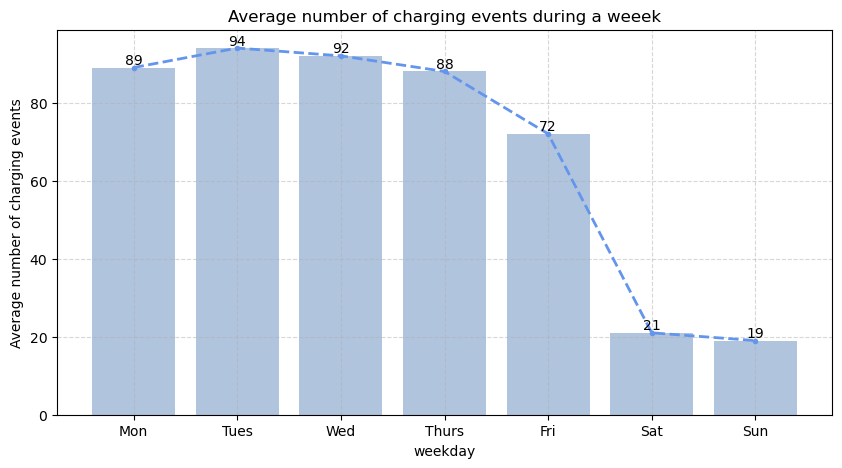

In [282]:
fig=plt.figure(figsize=(10,5))
x=Day_counts['Weekday']
y=Day_counts['Vehicle_charging_Counts']
plt.plot(x, y, color='cornflowerblue',marker='.',linestyle='--',linewidth=2,label='Line Chart')
plt.title('Average number of charging events during a weeek')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(ticks=range(len(x)), labels=x)  
plt.xlabel('weekday')
plt.ylabel('Average number of charging events')
plt.bar(x,y,color='lightsteelblue')

During weekdays (Monday to Friday), charging demand remains high, peaking on Tuesday and Wednesday with around 94 and 92 events, respectively, before slightly decreasing to 72 events on Friday. This consistent demand during weekdays is likely driven by regular commuting. In contrast, charging events drop significantly over the weekend, with only 21 events on Saturday and 19 on Sunday, possibly because people travel less and prefer home charging. 

### seperating site1 and site 2

In [283]:
def analyze_week_charging(df):
    df.index.dayofweek
    # the number of weekdays
    unique_dates = df.index.normalize().unique()
    Monday_count =(pd.to_datetime(unique_dates).dayofweek == 0).sum()
    print("Number of Mondays:",Monday_count)
    Tuesday_count =(pd.to_datetime(unique_dates).dayofweek == 1).sum()
    print("Number of Tuesdays:",Tuesday_count)
    Wednesday_count =(pd.to_datetime(unique_dates).dayofweek == 2).sum()
    print("Number of Wednesdays:",Wednesday_count)
    Thursday_count =(pd.to_datetime(unique_dates).dayofweek == 3).sum()
    print("Number of Thursdays:",Thursday_count)
    Friday_count =(pd.to_datetime(unique_dates).dayofweek == 4).sum()
    print("Number of Fridays:",Friday_count)
    Saturday_count =(pd.to_datetime(unique_dates).dayofweek == 5).sum()
    print("Number of Saturdays:",Saturday_count)
    Sunday_count =(pd.to_datetime(unique_dates).dayofweek == 6).sum()
    print("Number of Sundays:",Sunday_count)
    day_counts=pd.Series([Monday_count, Tuesday_count, Wednesday_count, Thursday_count, Friday_count, Saturday_count, Sunday_count],
                     index=['Mon','Tues','Wed','Thurs','Fri','Sat','Sun'])
    print(day_counts)
    average_numbe_of_charging=weekday/day_counts
    average_numbe_of_charging=average_numbe_of_charging.round().astype(int)
    Day_counts= average_numbe_of_charging.reset_index()
    Day_counts.columns = ['Weekday', 'Vehicle_charging_Counts']
    Day_counts
    fig=plt.figure(figsize=(10,5))
    x=Day_counts['Weekday']
    y=Day_counts['Vehicle_charging_Counts']
    plt.bar(x, y,color='lightsteelblue')
    plt.title('Average number of charging events during a weeek')
    for (a,b) in zip(x,y):
        plt.text(x=a,y=b,s=b,ha='center',va='bottom')
        plt.grid(ls="--",alpha=0.5)
        plt.xticks(ticks=range(len(x)), labels=x)  
        plt.xlabel('weekday')
        plt.ylabel('Average number of charging events')
        plt.bar(x,y)

Number of Mondays: 131
Number of Tuesdays: 131
Number of Wednesdays: 131
Number of Thursdays: 131
Number of Fridays: 131
Number of Saturdays: 116
Number of Sundays: 115
Mon      131
Tues     131
Wed      131
Thurs    131
Fri      131
Sat      116
Sun      115
dtype: int32


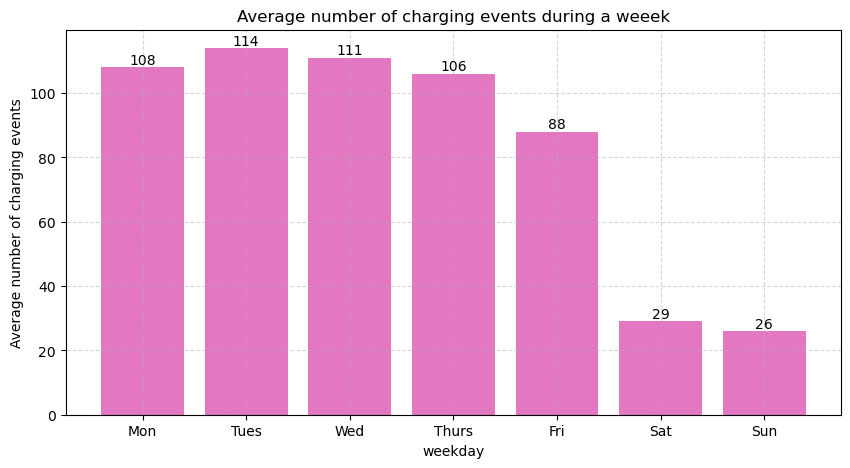

In [284]:
analyze_week_charging(site1)

Number of Mondays: 147
Number of Tuesdays: 146
Number of Wednesdays: 145
Number of Thursdays: 143
Number of Fridays: 143
Number of Saturdays: 150
Number of Sundays: 147
Mon      147
Tues     146
Wed      145
Thurs    143
Fri      143
Sat      150
Sun      147
dtype: int32


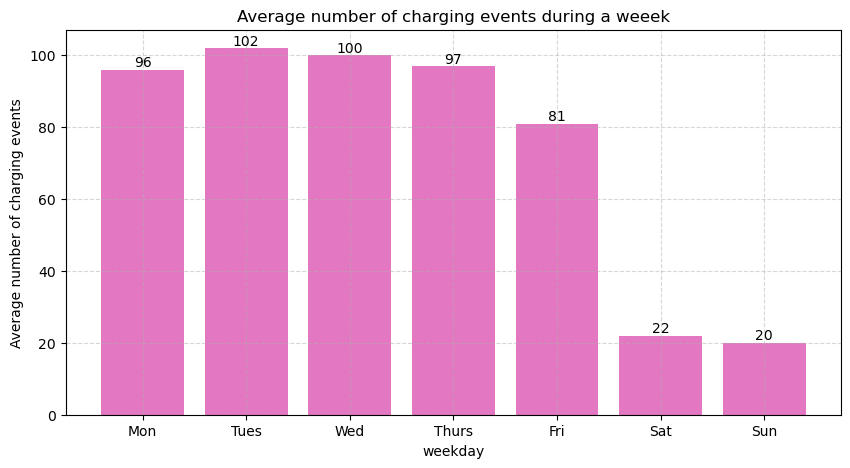

In [285]:
analyze_week_charging(site2)

### Charging patterns during a weekday and a weekend

In [286]:
week=np.where(df.index.weekday<5,'weekday','weekend')
charging_events_per_hour=df.groupby([week,df.index.hour]).size()
print(charging_events_per_hour)

         time
weekday  0         110
         1          49
         2          90
         3         170
         4         543
         5        2996
         6        9456
         7       12848
         8        8342
         9        6256
         10       3535
         11       3043
         12       3751
         13       3114
         14       2736
         15       2958
         16       2601
         17       1723
         18       1535
         19       1169
         20        817
         21        594
         22        387
         23        200
weekend  0          69
         1          29
         2          15
         3          12
         4          22
         5          66
         6         114
         7         308
         8         370
         9         536
         10        581
         11        472
         12        539
         13        479
         14        453
         15        404
         16        425
         17        341
         18        2

In [287]:
weekday_charging_events_per_hour=charging_events_per_hour['weekday']/(162*5)
weekday_charging_events_per_hour=weekday_charging_events_per_hour.round().astype(int)
weekend_charging_events_per_hour=charging_events_per_hour['weekend']/(160*2)
weekend_charging_events_per_hour=weekend_charging_events_per_hour.round().astype(int)
print(weekday_charging_events_per_hour)

time
0      0
1      0
2      0
3      0
4      1
5      4
6     12
7     16
8     10
9      8
10     4
11     4
12     5
13     4
14     3
15     4
16     3
17     2
18     2
19     1
20     1
21     1
22     0
23     0
dtype: int32


In [288]:
print(weekend_charging_events_per_hour)

time
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     1
8     1
9     2
10    2
11    1
12    2
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    0
23    0
dtype: int32


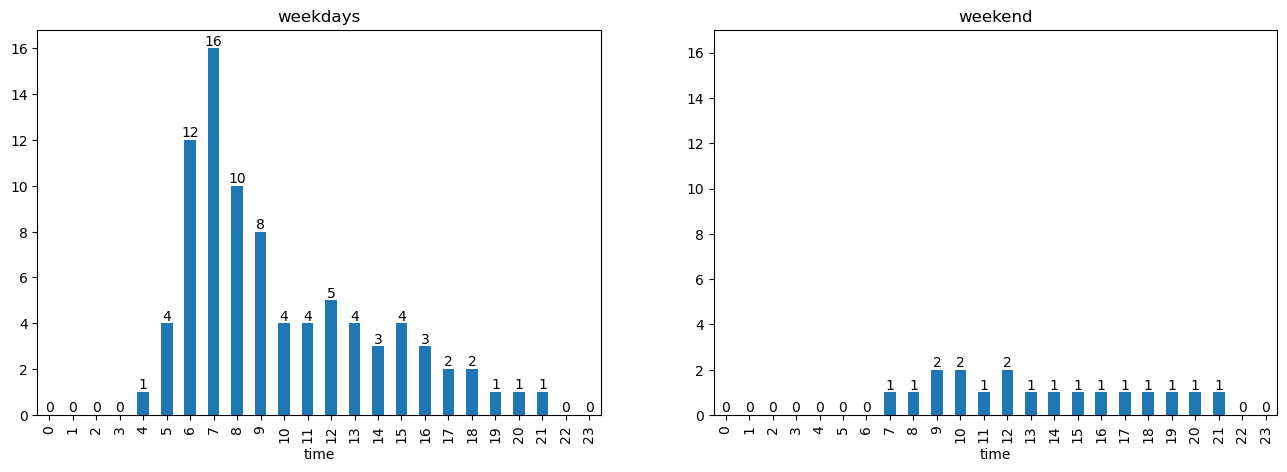

In [289]:
fig,ax=plt.subplots(1,2,figsize=(16,5))
y_min,y_max=0,17
weekday_bars=weekday_charging_events_per_hour.plot(kind='bar',ax=ax[0],title='weekdays')
for bar in weekday_bars.patches:
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 
weekend_bars=weekend_charging_events_per_hour.plot(kind='bar',ax=ax[1],title='weekend')
ax[1].set_ylim(y_min, y_max)
for bar in weekend_bars.patches:
    ax[1].text(bar.get_x() + bar.get_width()/2,bar.get_height(),f'{int(bar.get_height())}',ha='center', va='bottom') 

## between the seasons

### Seasonality

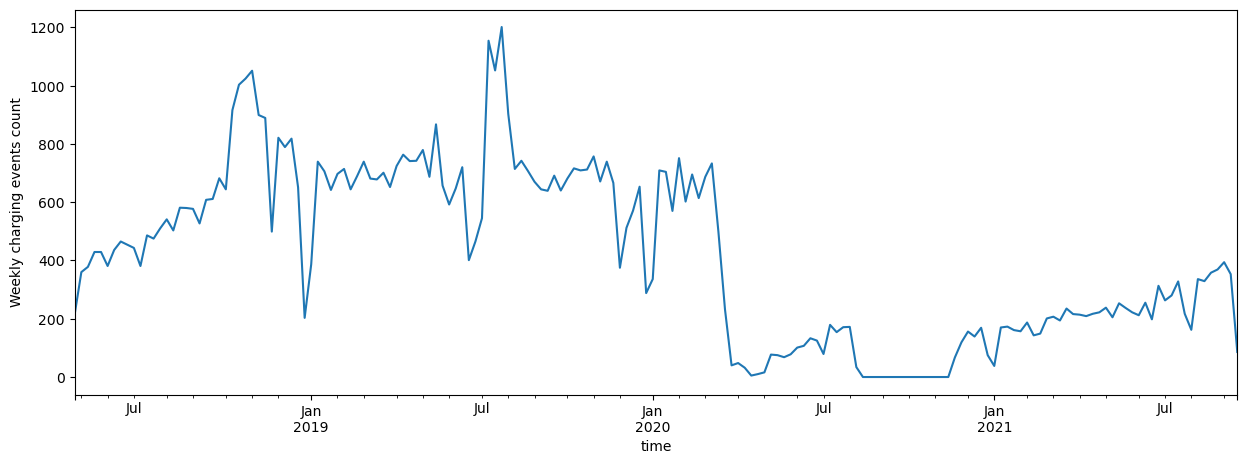

In [329]:
# resample accroding to week
weekly=df.resample('W').size()
weekly.plot()
plt.ylabel('Weekly charging events count')
rcParams['figure.figsize'] = 15, 5

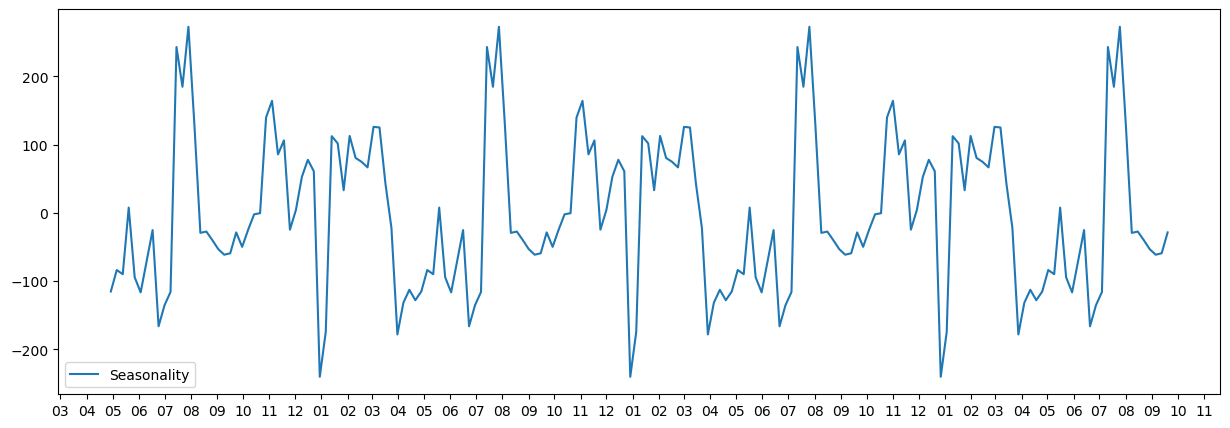

In [331]:
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.dates import DateFormatter, MonthLocator
decomposition = seasonal_decompose(weekly)
seasonal = decomposition.seasonal
ax = plt.gca()
ax.xaxis.set_major_formatter(DateFormatter('%m')) 
ax.xaxis.set_major_locator(MonthLocator())    
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')


This graph shows that the number of charging sessions exhibits a regular pattern that repeats annually. In spring, charging demand gradually decreases as the weather warms up and battery performance stabilizes, reducing the need for frequent charging. During summer, charging frequency rises sharply, peaking in July or August due to increased use of air conditioning and cooling equipment driven by higher temperatures. In autumn, charging demand gradually declines again as moderate temperatures improve device efficiency, leading to lower charging needs. In winter, charging demand decreases further, reaching its lowest point in January. This decline is likely due to reduced activity near workplaces and schools during major holidays, such as Christmas, New Year, and winter vacation.

In [123]:
def get_season(month):
    if month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    elif month in [9,10,11]:
        return "Autumn"
    else:
        return "Winter"

In [124]:
df['month']=df.index.month
df['season']=df['month'].apply(get_season)
df['season']

time
2020-01-02 05:08:54    Winter
2020-01-02 05:36:50    Winter
2020-01-02 05:56:35    Winter
2020-01-02 05:59:58    Winter
2020-01-02 05:59:58    Winter
                        ...  
2019-07-31 11:08:04    Summer
2019-07-31 11:40:41    Summer
2019-07-31 12:04:40    Summer
2019-07-31 12:19:47    Summer
2019-07-31 12:21:47    Summer
Name: season, Length: 75329, dtype: object

In [125]:
number_in_season=df['season'].value_counts()
number_in_season

season
Summer    21454
Autumn    19746
Winter    17944
Spring    16185
Name: count, dtype: int64

In [126]:
unique_season=df['season'].loc[df['season']!=df['season'].shift(1)]
season_counts=unique_season.value_counts()
print(season_counts)

season
Winter    9
Summer    8
Autumn    8
Spring    7
Name: count, dtype: int64


In [127]:
average_number_in_different_season=number_in_season/season_counts
average_number_in_different_season=average_number_in_different_season.astype(int)

In [128]:
average_number_in_different_season= average_number_in_different_season.reset_index()
average_number_in_different_season.columns = ['season', 'Vehicle_charging_Counts']
average_number_in_different_season

,season,Vehicle_charging_Counts
0,Autumn,2468
1,Spring,2312
2,Summer,2681
3,Winter,1993


<BarContainer object of 4 artists>

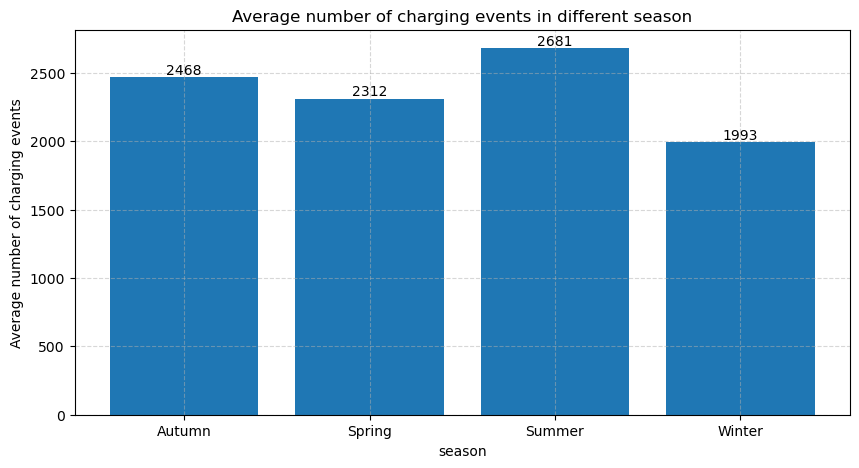

In [129]:
fig=plt.figure(figsize=(10,5))
x=average_number_in_different_season['season']
y=average_number_in_different_season['Vehicle_charging_Counts']
plt.title('Average number of charging events in different season')
for (a,b) in zip(x,y):
    plt.text(x=a,y=b,s=b,ha='center',va='bottom')
plt.grid(ls="--",alpha=0.5)
plt.xticks(ticks=range(len(x)), labels=x)  
plt.xlabel('season')
plt.ylabel('Average number of charging events')
plt.bar(x,y)

Summer has the highest number of charging events, with 2681 events, likely due to high temperatures reducing battery efficiency and increased energy consumption from air conditioning. Autumn and spring show moderate demand, with 2468 and 2312 events, respectively, as mild weather conditions result in stable battery performance. Winter has the lowest demand, with 1993 events, possibly because Winter typically includes more holidays (such as Christmas and New Year), during which students and atsff are on vacation.

Since the winter of 2020, due to the implementation of pandemic control measures such as remote working, travel restrictions, and reduced non-essential outings, the frequency of commuting and travel has significantly decreased, directly leading to a reduction in the usage of public charging stations. Therefore, the low charging demand during winter may not only be related to cold weather but also influenced by the pandemic, especially during periods of severe outbreaks or strict lockdown measures.

### separate site1 and site 2

In [96]:
def analyze_season_charging(df):
    df['month']=df.index.month
    df['season']=df['month'].apply(get_season)
    number_in_season=df['season'].value_counts()
    unique_season=df['season'].loc[df['season']!=df['season'].shift(1)]
    season_counts=unique_season.value_counts()
    average_number_in_different_season=number_in_season/season_counts
    average_number_in_different_season=average_number_in_different_season.astype(int)
    average_number_in_different_season= average_number_in_different_season.reset_index()
    average_number_in_different_season.columns = ['season', 'Vehicle_charging_Counts']
    fig=plt.figure(figsize=(10,5))
    x=average_number_in_different_season['season']
    y=average_number_in_different_season['Vehicle_charging_Counts']
    plt.title('Average number of charging events in different season')
    for (a,b) in zip(x,y):
        plt.text(x=a,y=b,s=b,ha='center',va='bottom')
    plt.grid(ls="--",alpha=0.5)
    plt.xticks(ticks=range(len(x)), labels=x)  
    plt.xlabel('season')
    plt.ylabel('Average number of charging events')
    plt.bar(x,y)

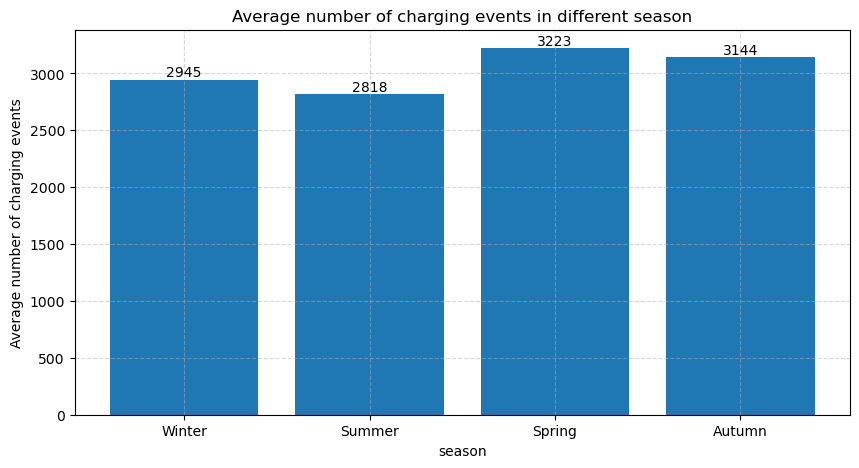

In [97]:
analyze_season_charging(site1)

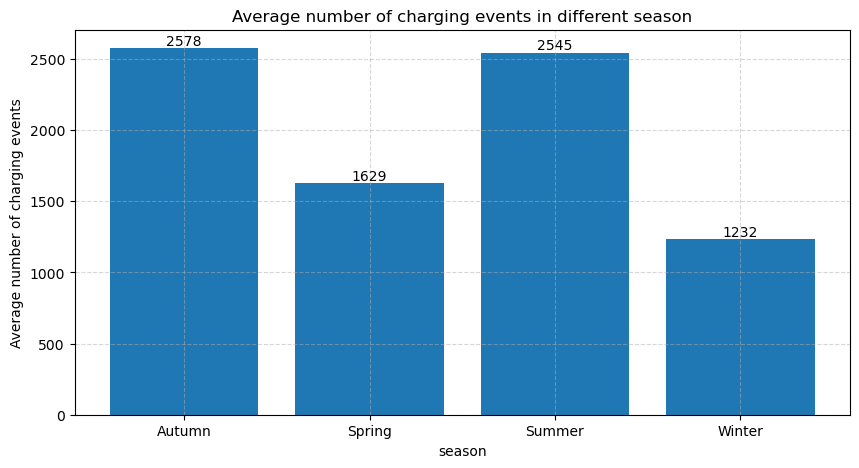

In [98]:
analyze_season_charging(site2)

Site 1 is likely the private site (company) because its charging activity remains relatively consistent across all seasons, with no significant seasonal fluctuations. Additionally, the usage frequency drops significantly on weekends, which aligns with a typical employee work pattern where charging primarily occurs on weekdays. The peak charging hours are between 7:00 AM and 9:00 AM, matching common commuting times for employees.


Site 2 is likely the public site (university) due to noticeable seasonal variations in charging activity, with lower usage during spring and winter, corresponding to the school’s spring break and winter holiday periods. Although the weekend usage is also low, it is slightly higher than at Site 1, indicating occasional weekend activity, such as student or staff visits. Furthermore, the peak charging hours are more spread out throughout the day, reflecting the diverse schedules of students and faculty.